# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [7]:
from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Boundaries, U

R = 1.
r = 0.2


lc = 2.

# mesh = AnularDomain(R=R, r=r, verbosity=0, Lc=lc, lc=lc)
# mesh = CleanCircle(R=R, verbosity=0, lc=lc)
R = 0.1
mesh = U(R=R, verbosity=0, Lc=lc, lc=lc)


In [5]:
mesh.n_triangles

559

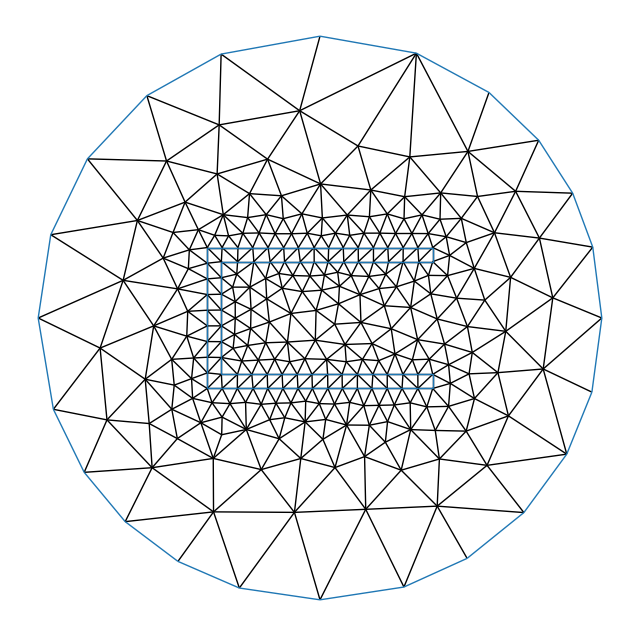

In [6]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [ ]:
mesh.curve_boundary(Boundaries.SIGMA, radius=R)


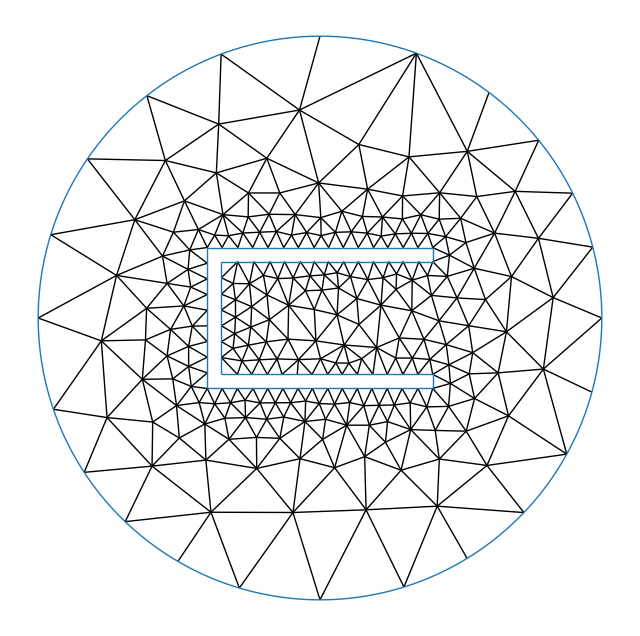

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = PlaneWave(d=np.array([-1., 0.]), A=-1.)
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=None), Boundaries.D_OMEGA: DirichletBC(data=data)}
# boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [11]:
# from trefftz.dg.assemblers import SerialNumerics
# NtD_modes = 15
# a = 0.5
# b = 0.5
# d2 = 0.5
# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

In [12]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 20
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [65]:
from trefftz.dg.basis import LinearlySpacedBasis
from scipy.constants import c
f = 16E9
k = 2*np.pi*f/c
print(k)
Ntheta = 19
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

335.33520351226906


and an assembler:

In [66]:
basis.N_DOF

9215

In [67]:
# from trefftz.dg.assemblers import SerialAssembler

# assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [68]:
assembler._regions_RHS_term

[<Boundaries.D_OMEGA: 'd_Omega'>]

so we can set the problem:

In [69]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [70]:
A = P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 23/23 [00:03<00:00,  6.13edge/s]


region: d_Omega


Interior: 100%|██████████| 678/678 [00:00<00:00, 1166.05edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 23/23 [04:30<00:00, 11.76s/edge]


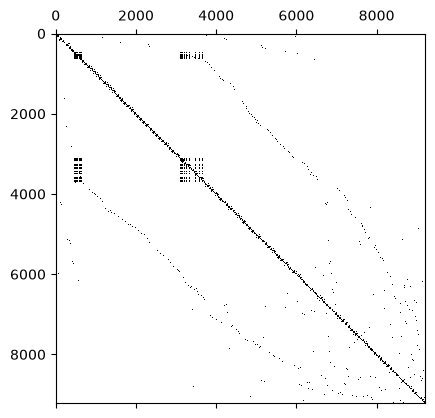

In [71]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [72]:
b = P.assemble_RHS()

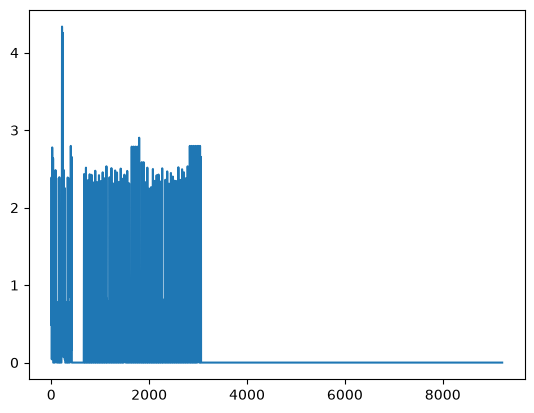

In [73]:
import numpy as np 
plt.plot(np.abs(b))

In [74]:
P.solve()

In [75]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 5.08992292e+04-2.99052555e+05j, -1.97540176e+05-2.38742321e+05j,
        -2.72710120e+03+3.08793740e+05j, ...,
         1.02262429e+05+2.29933256e+05j, -2.70764844e+05+3.79010541e+04j,
        -8.66033983e+04-2.77619190e+05j],
       [-4.65497789e+05-1.09809593e+05j, -1.63846761e+05+4.37488085e+05j,
         1.47797667e+05-4.17122926e+05j, ...,
         4.53057300e+05+2.07467086e+04j, -2.02965775e+05+4.23530493e+05j,
        -4.73302508e+05-6.88971233e+04j],
       [-2.49228592e+04-1.81373684e+05j, -1.53406134e+05-9.13767129e+04j,
         8.13842468e+04+1.49464318e+05j, ...,
         1.84592095e+05+6.53139528e+04j, -1.45632271e+05+1.22123108e+05j,
        -1.17736841e+05-1.44129473e+05j],
       ...,
       [-2.44153316e+01+2.54125421e+00j,  1.50695244e+01+2.50387618e+01j,
         1.81142766e+01+3.05495525e+01j, ...,
         2.30003981e+00+2.10893221e+00j,  6.63042184e+00+5.50058580e+00j,
         1.11171697e+01+1.28242884e+01j],
       [-7.13178815e+01+2.85686070e+01j,  7.

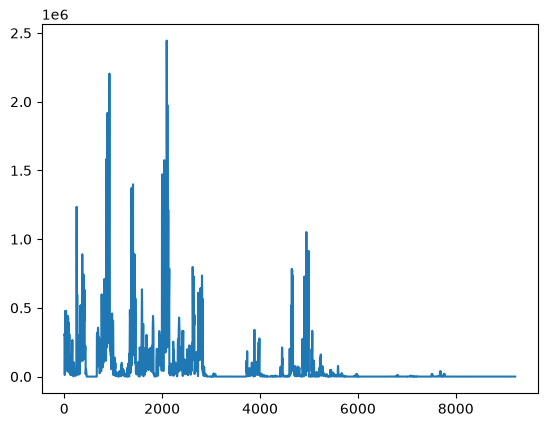

In [76]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [77]:
import numpy as np
# N = 200
# # rs = np.linspace(r, R, N)
# rs = np.linspace(0, R, N)

# theta = np.linspace(0, 2*np.pi, N)
# Rs, Theta = np.meshgrid(rs, theta)
# X = Rs*np.cos(Theta)
# Y = Rs*np.sin(Theta)
# x = X.ravel()
# y = Y.ravel() 
# z = P.u_h(x, y)

In [78]:
import matplotlib.pyplot as plt
# plt.scatter(x,y,c=np.real(z),cmap="viridis")
# plt.axis("square")

(np.float64(-0.1), np.float64(0.1), np.float64(-0.1), np.float64(0.1))

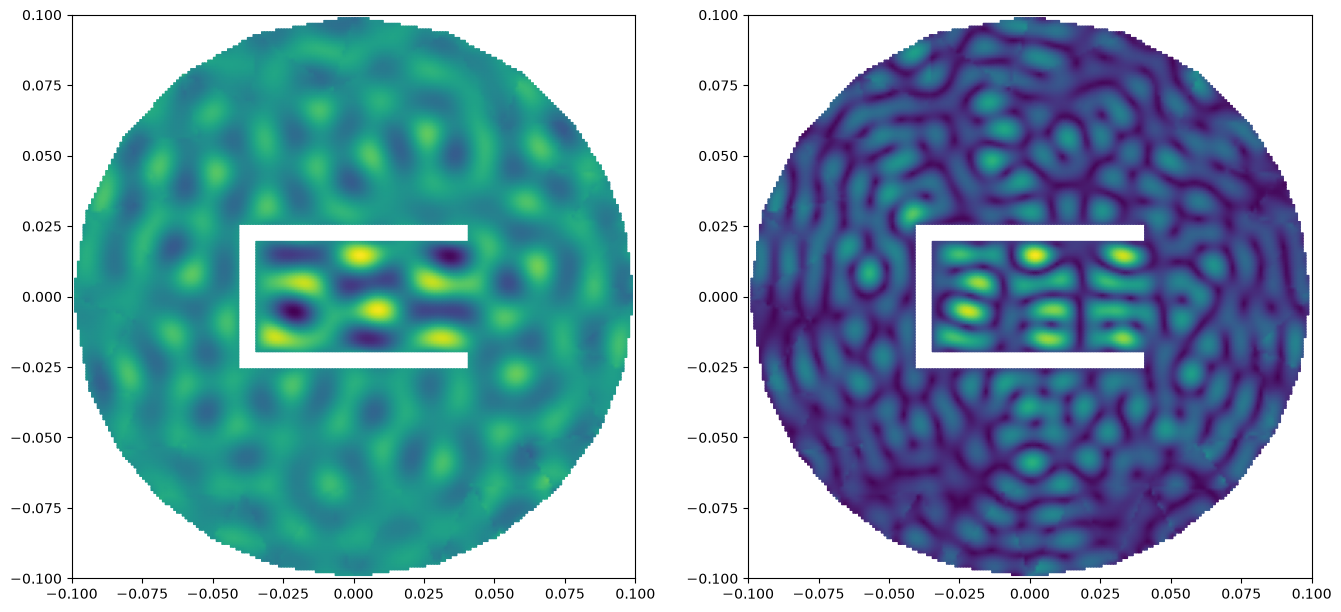

In [79]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = P.u_h(X, Y)

RHO = np.sqrt(X**2 + Y**2)
THETA = np.arctan2(Y,X)
from scipy.special import jn, hankel1

Z_exact = -sum( 1j**n*jn(n, k*r)*hankel1(n, k*RHO)/hankel1(n, k*r)*np.exp(1j*n*(THETA-np.pi)) for n in range(-50,51))
Z_exact[RHO < r ] = np.nan
Z_exact[RHO > R ] = np.nan

import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(Z_exact.real)
vmax = np.max(Z_exact.real)


ax[0].pcolormesh(X, Y, np.real(Z), shading="gouraud")
ax[0].axis('square')
# ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
# ax[1].axis('square')
ax[1].pcolormesh(X, Y, np.abs(Z + np.exp(-1j*k*X)), shading="gouraud")
ax[1].axis('square')


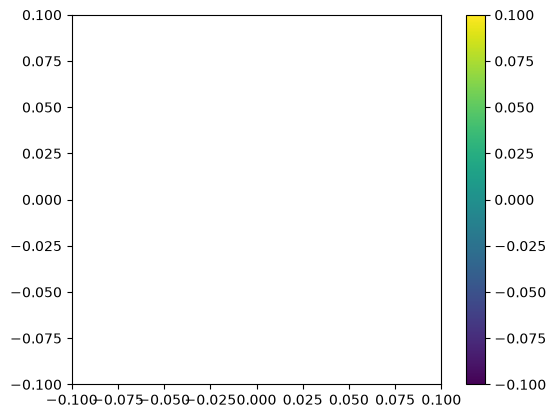

In [80]:
plt.pcolormesh(X, Y, np.abs(Z - Z_exact), shading="gouraud")
plt.axis("square")
plt.colorbar()